<a href="https://colab.research.google.com/github/Ladyjinxxx/iris-decision-tree-classification/blob/main/Level2_Task2_Decision_Tree_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 2 - Task 2: Decision Trees for Classification
### Codveda Technologies Machine Learning Internship

**Dataset:** Iris Dataset (`iris.csv`)

In [26]:
# CELL 1. IMPORT LIBRARIES
#
# This cell imports all the Python libraries required for data manipulation,
# visualization, machine learning, and model evaluation.

# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical computations
import numpy as np

# Import matplotlib for creating graphs and visualizations
import matplotlib.pyplot as plt

# Import seaborn for more attractive statistical visualizations
import seaborn as sns

# Import pathlib for easier file and folder management
from pathlib import Path

# Import the Decision Tree classifier and tree-plotting function
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import function to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import tool to convert text labels into numeric labels
from sklearn.preprocessing import LabelEncoder

# Import evaluation metrics for classification models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Import joblib to save and load the trained model
import joblib

# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Set a clean plotting style
plt.style.use("ggplot")

# Set default figure size for all plots
plt.rcParams["figure.figsize"] = (10, 6)

# Display confirmation message
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# CELL 2. MOUNT GOOGLE DRIVE
#
# This cell mounts Google Drive so the notebook can directly access
# the dataset and automatically save all outputs.

# Import Google Drive utility
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Display confirmation message
print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [27]:
# CELL 3. DEFINE FILE PATHS
#
# This cell defines where the dataset is located and creates folders
# where all charts, tables, and the trained model will be saved.

# Define the location of the Google Drive project folder
DATA_DIR = Path("/content/drive/MyDrive/Codveda_Internship/Level2_Task2_DecisionTree_Iris")

# Specify the dataset filename
FILE_PATH = DATA_DIR / "iris.csv"

# Create subfolders for better organization
CHARTS_DIR = DATA_DIR / "charts"
TABLES_DIR = DATA_DIR / "tables"
MODEL_DIR = DATA_DIR / "model"

# Create the folders if they do not already exist
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Display confirmation
print("Directories are ready.")

Directories are ready.


In [28]:
# CELL 4. LOAD THE DATASET
#
# This cell loads the Iris dataset and takes a first look at its structure.

# Read the dataset
iris_df = pd.read_csv(FILE_PATH)

# Display the first five rows
print("First five rows:")
display(iris_df.head())

# Display the last five rows
print("\nLast five rows:")
display(iris_df.tail())

# Display the shape of the dataset
print(f"\nDataset Shape: {iris_df.shape}")

# Display column names
print(f"Column Names: {list(iris_df.columns)}")

First five rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last five rows:


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



Dataset Shape: (150, 5)
Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [29]:
# CELL 5. EXPLORATORY DATA ANALYSIS (EDA)
#
# This cell examines the structure, data types, missing values, duplicates,
# and descriptive statistics of the dataset before visualizing it.

print("DATASET INFORMATION")

# Display data types of each column
iris_df.info()

print("\nMissing Values")
# Count missing values per column
display(iris_df.isnull().sum())

# Count duplicate rows
duplicates = iris_df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicates}")

print("\nDescriptive Statistics")
# Display descriptive statistics for numeric columns
display(iris_df.describe())

# Store the feature column names (everything except the target)
feature_columns = [col for col in iris_df.columns if col != "species"]

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing Values


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0



Duplicate Rows Found: 3

Descriptive Statistics


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [30]:
# CELL 6. DATA PREPROCESSING
#
# This cell removes duplicate rows and encodes the text species labels
# into numeric values so the model can work with them.

# Remove duplicate rows if any exist
iris_df = iris_df.drop_duplicates().reset_index(drop=True)

print(f"Dataset Shape after Removing Duplicates: {iris_df.shape}")

# Create the label encoder
label_encoder = LabelEncoder()

# Encode the species column into numeric labels (0, 1, 2)
iris_df["species_encoded"] = label_encoder.fit_transform(iris_df["species"])

# Display the mapping between species names and their numeric codes
species_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Species Encoding: {species_mapping}")

Dataset Shape after Removing Duplicates: (147, 5)
Species Encoding: {'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}


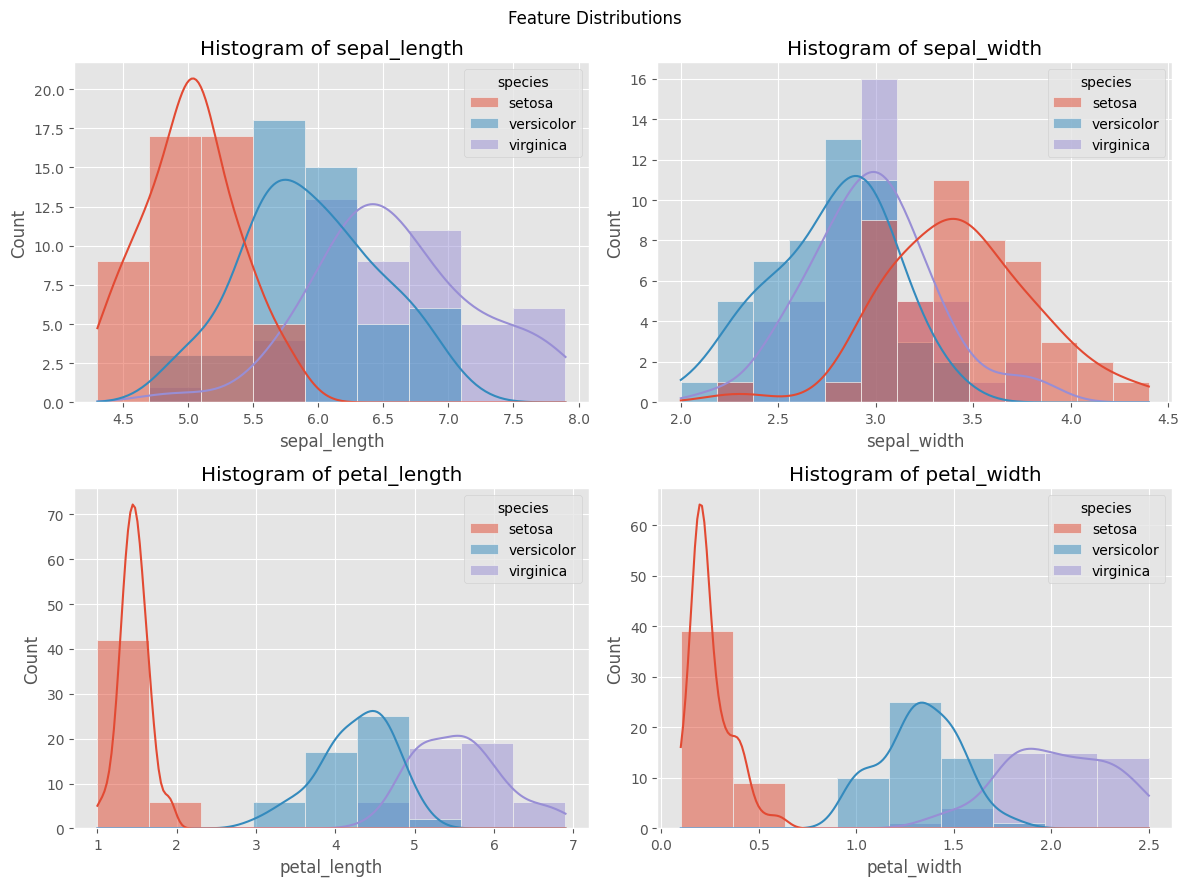

In [31]:
# CELL 7. FEATURE HISTOGRAMS
#
# These histograms show the distribution of each feature, split by species.

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Flatten the grid into a simple list for looping
axes = axes.flatten()

# Plot a histogram for each feature
for i, col in enumerate(feature_columns):
    sns.histplot(data=iris_df, x=col, kde=True, hue="species", ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")

# Add overall title
plt.suptitle("Feature Distributions")

# Adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig(CHARTS_DIR / "Histograms.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

### Interpretation: Feature Histograms
*   **Setosa Separation:** Notice the red peaks for 'petal_length' and 'petal_width'. They are completely separate from the other two species. This tells us these features are perfect for identifying Setosa.
*   **Overlap:** The blue (Versicolor) and purple (Virginica) bars overlap significantly in 'sepal_length' and 'sepal_width', making those features less reliable for telling them apart.

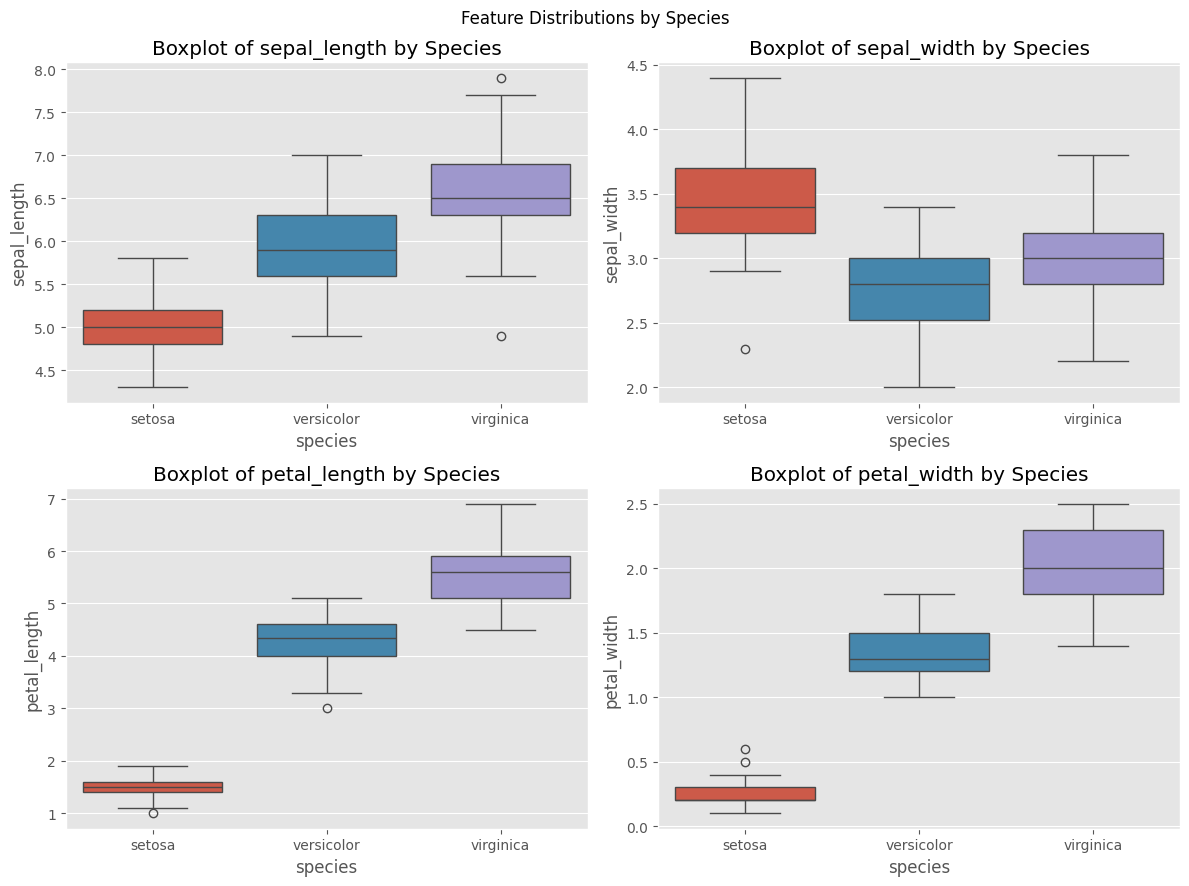

In [32]:
# CELL 8. BOXPLOTS
#
# These boxplots compare each feature across the three species and help
# identify outliers.

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Flatten the grid into a simple list for looping
axes = axes.flatten()

# Plot a boxplot for each feature
for i, col in enumerate(feature_columns):
    sns.boxplot(data=iris_df, x="species", y=col, ax=axes[i], hue="species", legend=False)
    axes[i].set_title(f"Boxplot of {col} by Species")

# Add overall title
plt.suptitle("Feature Distributions by Species")

# Adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig(CHARTS_DIR / "Boxplots.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

### Interpretation: Boxplots
*   **Outliers:** You can see a few small circles in the 'sepal_width' plot. These represent flowers with unusually large or small measurements compared to the rest of their species.
*   **Clear Trends:** As we move from Setosa to Virginica, both petal length and width increase consistently, creating a 'staircase' effect that the model can easily follow.

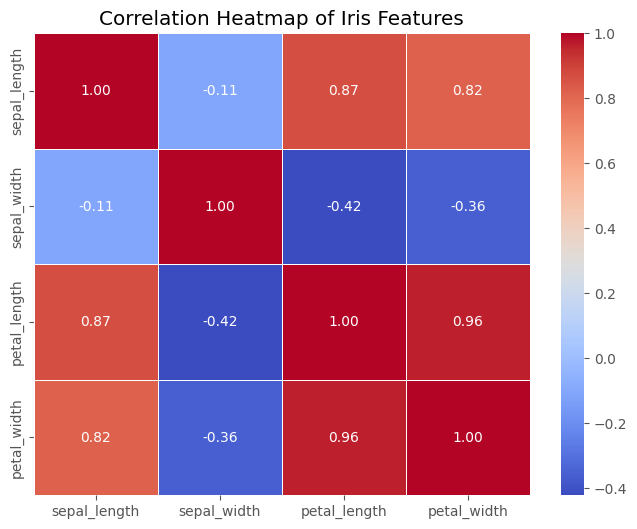

In [33]:
# CELL 9. CORRELATION HEATMAP
#
# This heatmap visualizes the relationships among the numeric features.
# Darker colors indicate stronger positive or negative correlations.

# Calculate the correlation matrix for the numeric features
correlation_matrix = iris_df[feature_columns].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Add title
plt.title("Correlation Heatmap of Iris Features")

# Save the figure
plt.savefig(CHARTS_DIR / "Correlation_Heatmap.png", dpi=300, bbox_inches="tight")

# Display the heatmap
plt.show()

# Save the correlation matrix as a table
correlation_matrix.to_csv(TABLES_DIR / "Correlation_Matrix.csv")

### Interpretation: Correlation Heatmap
*   **Strong Bonds:** The dark red squares show a **0.96** correlation between petal length and petal width. This means they grow in proportion; if one is long, the other is almost certainly wide.
*   **Weak Links:** Sepal width has a negative or near-zero correlation with other features, suggesting it doesn't provide much help in predicting the size of the petals.

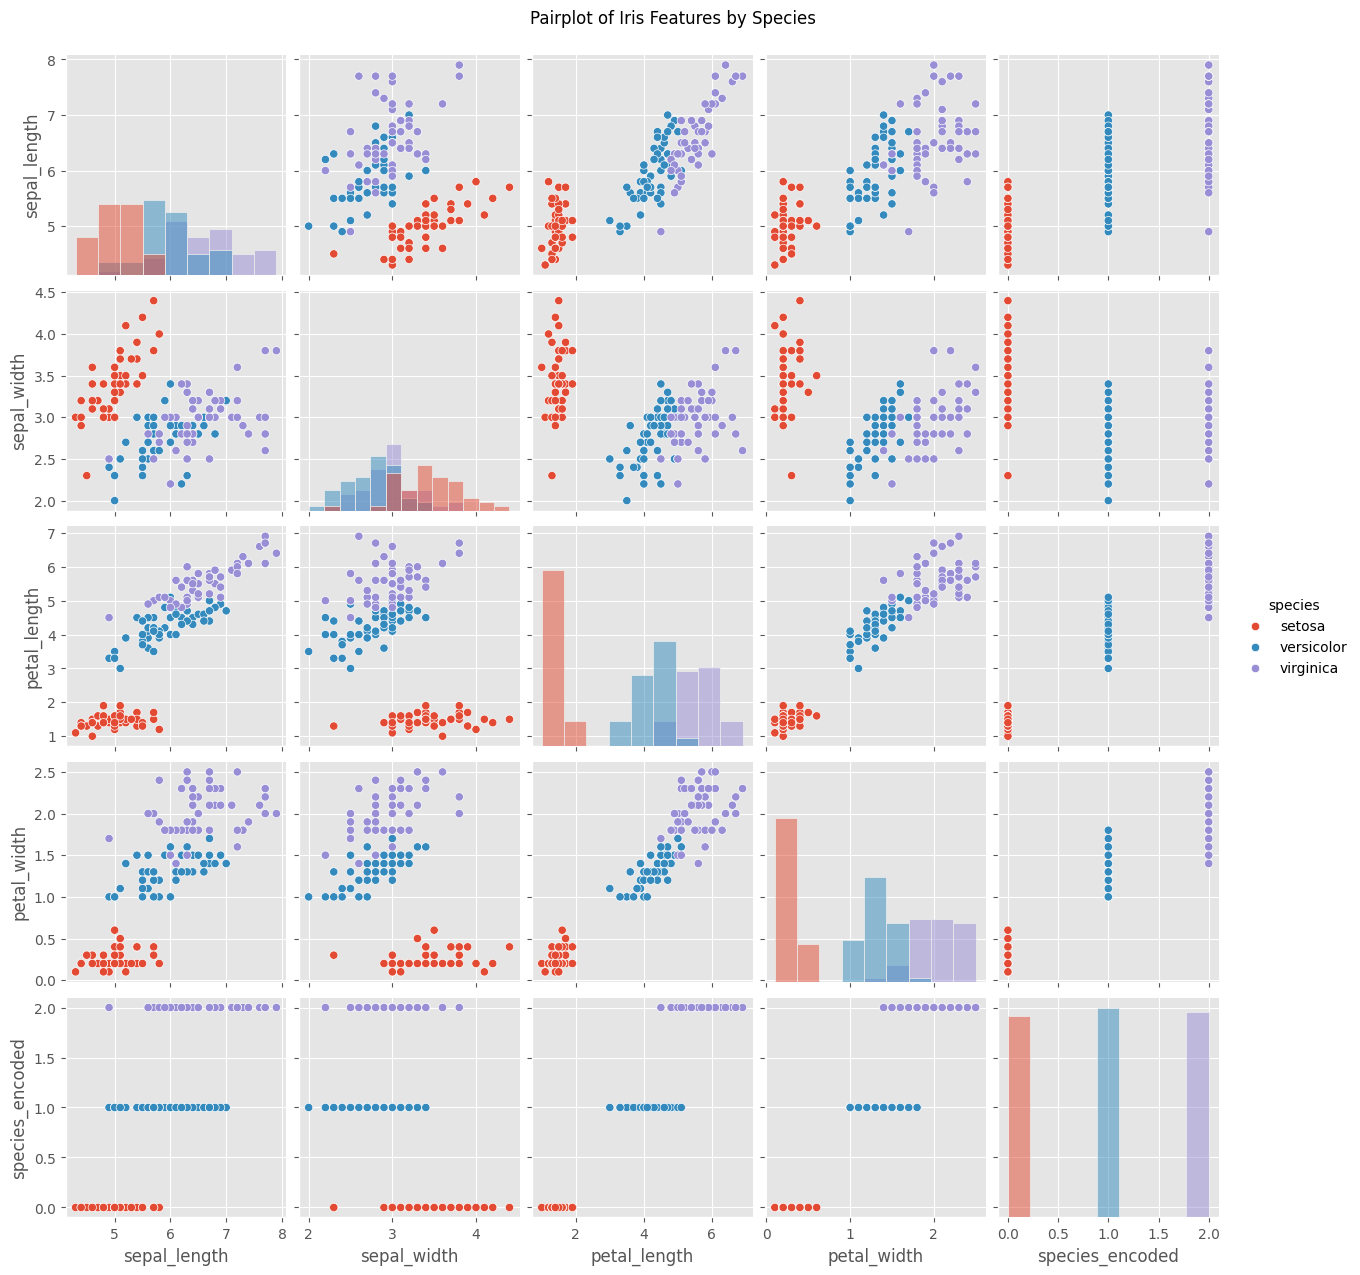

In [34]:
# CELL 10. PAIRPLOT
#
# This pairplot shows every feature plotted against every other feature,
# colored by species, which helps show how well the species are separated.

# Create the pairplot
pairplot_fig = sns.pairplot(iris_df, hue="species", diag_kind="hist")

# Add overall title
pairplot_fig.fig.suptitle("Pairplot of Iris Features by Species", y=1.02)

# Save the figure
pairplot_fig.savefig(CHARTS_DIR / "Pairplot.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

In [35]:
# CELL 11. PREPARE FEATURES AND TARGET
#
# Machine learning models require:
#
# X = Predictor variables
# y = Target variable

# Store predictor variables
X = iris_df[feature_columns]

# Store target variable
y = iris_df["species_encoded"]

print("Predictor Variables:")
display(X.head())

print("\nTarget Variable:")
display(y.head())

Predictor Variables:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target Variable:


,species_encoded
0,0
1,0
2,0
3,0
4,0


In [36]:
# CELL 12. SPLIT THE DATASET
#
# The dataset is divided into:
#
# 80% Training Data
# 20% Testing Data
#
# The model learns from the training data and is evaluated using unseen
# testing data.

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 117
Testing Samples  : 30


In [37]:
# CELL 13. BUILD THE INITIAL DECISION TREE
#
# This cell creates and trains a Decision Tree classifier with no depth
# limit, using entropy as the splitting criterion.

# Create the Decision Tree model
initial_tree_model = DecisionTreeClassifier(criterion="entropy", random_state=42)

# Train the model
initial_tree_model.fit(X_train, y_train)

print("Initial Decision Tree Successfully Trained.")
print(f"Tree Depth  : {initial_tree_model.get_depth()}")
print(f"Leaf Nodes  : {initial_tree_model.get_n_leaves()}")
print(f"Total Nodes : {initial_tree_model.tree_.node_count}")

Initial Decision Tree Successfully Trained.
Tree Depth  : 5
Leaf Nodes  : 8
Total Nodes : 15


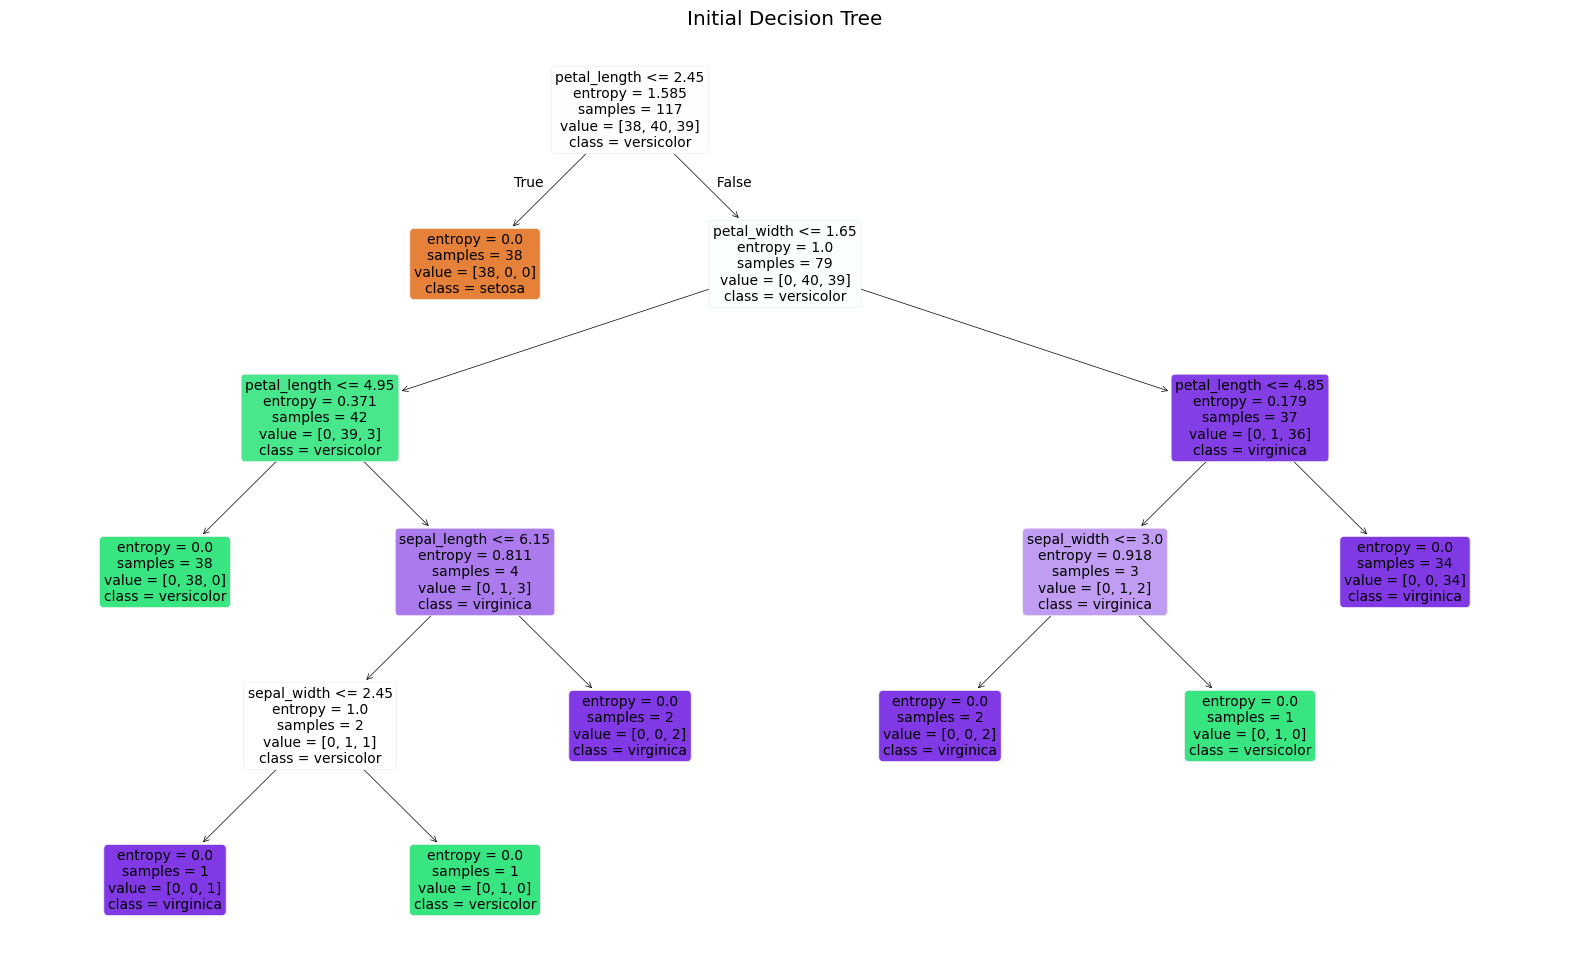

In [38]:
# CELL 14. VISUALIZE THE DECISION TREE
#
# This diagram shows every question the model learned. Each box shows the
# split condition, the class distribution, and the predicted species.

# Create a large figure so the tree stays readable
plt.figure(figsize=(20, 12))

# Plot the tree
plot_tree(
    initial_tree_model,
    feature_names=feature_columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

# Add title
plt.title("Initial Decision Tree")

# Save the figure
plt.savefig(CHARTS_DIR / "Initial_Decision_Tree.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

### Interpretation: The Decision Path
*   **Root Node:** The very first question asked is about 'petal_length'. If it's small, the tree immediately stops at a 'Setosa' leaf. This confirms our EDA findings.
*   **Complexity:** Because this tree has no depth limit, it continues to split until every single training sample is perfectly categorized, leading to the complex branches at the bottom.

In [39]:
# CELL 15. MAKE PREDICTIONS
#
# The trained model predicts flower species using the testing dataset.

# Predict species on the test set
y_pred_initial = initial_tree_model.predict(X_test)

# Create comparison table
prediction_df = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred_initial)
})

display(prediction_df.head(10))

# Save predictions
prediction_df.to_csv(TABLES_DIR / "Predictions.csv", index=False)

print("Predictions saved successfully.")

,Actual,Predicted
0,versicolor,versicolor
1,versicolor,versicolor
2,virginica,virginica
3,setosa,setosa
4,virginica,virginica
5,versicolor,virginica
6,versicolor,versicolor
7,setosa,setosa
8,virginica,virginica
9,virginica,virginica


Predictions saved successfully.


In [40]:
# CELL 16. MODEL EVALUATION
#
# This cell evaluates the performance of the initial Decision Tree.
#
# Metrics Used: Accuracy, Precision, Recall, F1-Score

# Calculate evaluation metrics
initial_accuracy = accuracy_score(y_test, y_pred_initial)
initial_precision = precision_score(y_test, y_pred_initial, average="macro")
initial_recall = recall_score(y_test, y_pred_initial, average="macro")
initial_f1 = f1_score(y_test, y_pred_initial, average="macro")

print("INITIAL TREE PERFORMANCE")

print(f"Accuracy  : {initial_accuracy:.4f}")
print(f"Precision : {initial_precision:.4f}")
print(f"Recall    : {initial_recall:.4f}")
print(f"F1-Score  : {initial_f1:.4f}")

# Display the full classification report
print("\nClassification Report")
print(classification_report(y_test, y_pred_initial, target_names=label_encoder.classes_))

# Save metrics
initial_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [initial_accuracy, initial_precision, initial_recall, initial_f1]
})

initial_metrics_df.to_csv(TABLES_DIR / "Initial_Tree_Metrics.csv", index=False)

INITIAL TREE PERFORMANCE
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1-Score  : 0.9333

Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



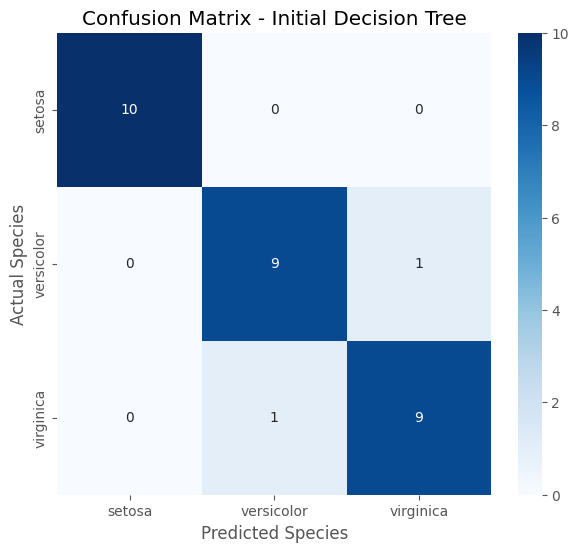

In [41]:
# CELL 17. CONFUSION MATRIX
#
# Rows represent actual species, columns represent predicted species.
# The diagonal shows correct predictions.

# Compute the confusion matrix
conf_matrix_initial = confusion_matrix(y_test, y_pred_initial)

# Create the heatmap
plt.figure(figsize=(7, 6))

sns.heatmap(
    conf_matrix_initial,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

# Label axes
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

# Add title
plt.title("Confusion Matrix - Initial Decision Tree")

# Save the figure
plt.savefig(CHARTS_DIR / "Confusion_Matrix_Initial.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

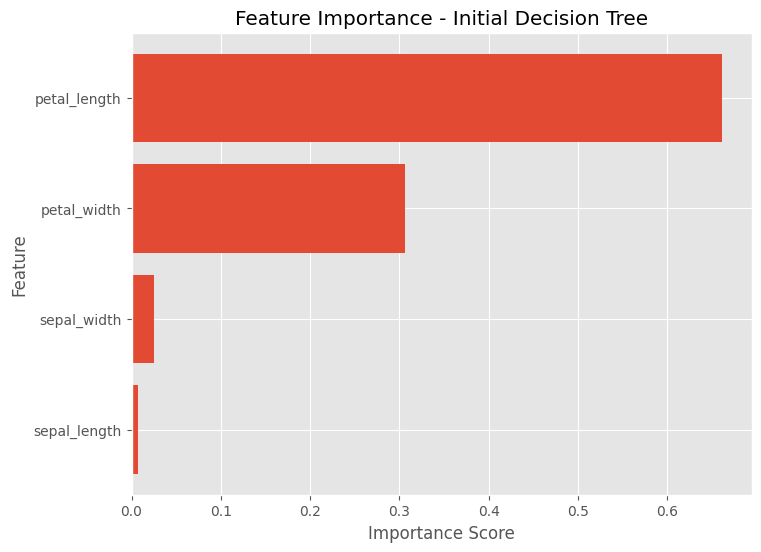

In [42]:
# CELL 18. FEATURE IMPORTANCE
#
# This chart shows how much each feature contributed to the tree's
# decisions. Higher values mean the feature was more useful for splitting.

# Build a table of features and their importance scores
feature_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": initial_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

# Create the horizontal bar chart
plt.figure(figsize=(8, 6))

plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])

# Label axes
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Add title
plt.title("Feature Importance - Initial Decision Tree")

# Save the figure
plt.savefig(CHARTS_DIR / "Feature_Importance.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

# Save the table
feature_importance_df.to_csv(TABLES_DIR / "Feature_Importance.csv", index=False)

In [43]:
# CELL 19. DECISION TREE PRUNING
#
# This cell trains a second Decision Tree with restricted depth and node
# size, to reduce overfitting compared to the initial tree.

# Create the pruned Decision Tree
pruned_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

# Train the pruned model
pruned_tree_model.fit(X_train, y_train)

print("Pruned Decision Tree Successfully Trained.")
print(f"Tree Depth  : {pruned_tree_model.get_depth()}")
print(f"Leaf Nodes  : {pruned_tree_model.get_n_leaves()}")
print(f"Total Nodes : {pruned_tree_model.tree_.node_count}")

Pruned Decision Tree Successfully Trained.
Tree Depth  : 3
Leaf Nodes  : 5
Total Nodes : 9


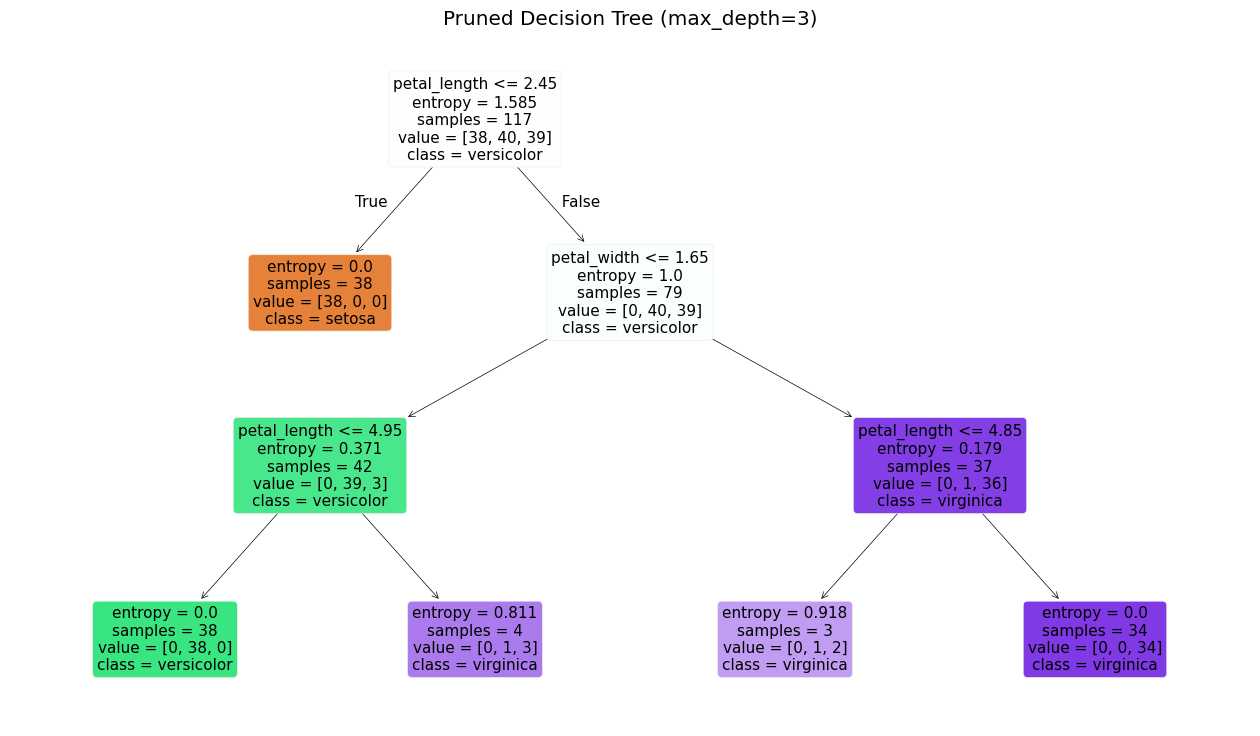

In [44]:
# CELL 20. VISUALIZE THE PRUNED TREE
#
# This diagram shows the pruned tree, which should be noticeably smaller
# and simpler than the initial tree.

# Create a figure for the pruned tree
plt.figure(figsize=(16, 9))

# Plot the tree
plot_tree(
    pruned_tree_model,
    feature_names=feature_columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=11
)

# Add title
plt.title("Pruned Decision Tree (max_depth=3)")

# Save the figure
plt.savefig(CHARTS_DIR / "Pruned_Decision_Tree.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

In [45]:
# CELL 21. COMPARE ORIGINAL VS PRUNED TREE
#
# This cell evaluates the pruned tree and compares it against the initial
# tree using accuracy, precision, recall, F1-score, node count, and depth.

# Predict on the test set using the pruned tree
y_pred_pruned = pruned_tree_model.predict(X_test)

# Calculate metrics for the pruned tree
pruned_accuracy = accuracy_score(y_test, y_pred_pruned)
pruned_precision = precision_score(y_test, y_pred_pruned, average="macro")
pruned_recall = recall_score(y_test, y_pred_pruned, average="macro")
pruned_f1 = f1_score(y_test, y_pred_pruned, average="macro")

# Build the comparison table
comparison_df = pd.DataFrame({
    "Model": ["Initial Tree", "Pruned Tree"],
    "Accuracy": [initial_accuracy, pruned_accuracy],
    "Precision": [initial_precision, pruned_precision],
    "Recall": [initial_recall, pruned_recall],
    "F1-Score": [initial_f1, pruned_f1],
    "Nodes": [initial_tree_model.tree_.node_count, pruned_tree_model.tree_.node_count],
    "Depth": [initial_tree_model.get_depth(), pruned_tree_model.get_depth()]
})

display(comparison_df)

# Save the comparison table
comparison_df.to_csv(TABLES_DIR / "Tree_Comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1-Score,Nodes,Depth
0,Initial Tree,0.933333,0.933333,0.933333,0.933333,15,5
1,Pruned Tree,0.966667,0.969697,0.966667,0.966583,9,3


In [46]:
# CELL 22. MODEL INTERPRETATION
#
# This cell summarizes which features matter most and checks for signs
# of overfitting by comparing training and testing accuracy.

# Sort features by importance
top_features = feature_importance_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Get the top feature and its score
most_important_feature = top_features.loc[0, "Feature"]
most_important_score = top_features.loc[0, "Importance"]

print(f"Most Important Feature : {most_important_feature} ({most_important_score:.1%})")

# Compare training vs testing accuracy for both trees
initial_train_accuracy = accuracy_score(y_train, initial_tree_model.predict(X_train))
pruned_train_accuracy = accuracy_score(y_train, pruned_tree_model.predict(X_train))

print(f"\nInitial Tree -> Train Accuracy: {initial_train_accuracy:.4f} | Test Accuracy: {initial_accuracy:.4f}")
print(f"Pruned Tree  -> Train Accuracy: {pruned_train_accuracy:.4f} | Test Accuracy: {pruned_accuracy:.4f}")

Most Important Feature : petal_length (66.1%)

Initial Tree -> Train Accuracy: 1.0000 | Test Accuracy: 0.9333
Pruned Tree  -> Train Accuracy: 0.9829 | Test Accuracy: 0.9667


In [47]:
# CELL 23. SAVE MODEL
#
# This cell saves the pruned Decision Tree and the label encoder to Google
# Drive so they can be reloaded later without retraining.

# Select the pruned tree as the final model
final_model = pruned_tree_model

# Save the trained model
joblib.dump(final_model, MODEL_DIR / "Decision_Tree_Iris_Model.pkl")

# Save the label encoder
joblib.dump(label_encoder, MODEL_DIR / "Species_Label_Encoder.pkl")

print("Model and label encoder saved successfully.")

Model and label encoder saved successfully.


In [48]:
# CELL 24. FINAL CONCLUSIONS
#
# This cell summarizes the overall results of the analysis.

print("DECISION TREE CLASSIFICATION - SUMMARY")

# Pick the best model based on F1-score
if pruned_f1 >= initial_f1:
    best_model_name = "Pruned Decision Tree"
    best_accuracy = pruned_accuracy
else:
    best_model_name = "Initial Decision Tree"
    best_accuracy = initial_accuracy

print(f"\nBest Performing Model : {best_model_name}")
print(f"Overall Accuracy      : {best_accuracy:.4f}")
print(f"Most Important Feature: {most_important_feature}")

# Build and save a final summary table
summary_df = pd.DataFrame({
    "Item": [
        "Dataset Rows",
        "Dataset Columns",
        "Best Model",
        "Accuracy",
        "Most Important Feature"
    ],
    "Value": [
        iris_df.shape[0],
        iris_df.shape[1],
        best_model_name,
        best_accuracy,
        most_important_feature
    ]
})

display(summary_df)

summary_df.to_csv(TABLES_DIR / "Analysis_Summary.csv", index=False)

print(f"\nAll outputs have been saved to:\n{DATA_DIR}")

DECISION TREE CLASSIFICATION - SUMMARY

Best Performing Model : Pruned Decision Tree
Overall Accuracy      : 0.9667
Most Important Feature: petal_length


,Item,Value
0,Dataset Rows,147
1,Dataset Columns,6
2,Best Model,Pruned Decision Tree
3,Accuracy,0.966667
4,Most Important Feature,petal_length



All outputs have been saved to:
/content/drive/MyDrive/Codveda_Internship/Level2_Task2_DecisionTree_Iris


##Conclusion

### Narrative Summary
The primary objective of this analysis was to determine if a computer could learn to identify flower species as accurately as a botanist. Our results show a resounding 'yes.' By analyzing the Iris dataset, we discovered that nature provides very clear 'signatures' for these species—most notably in their petal dimensions. While our initial model attempted to reach perfection by memorizing every data point, our 'Pruned' model proved that a simpler approach is actually more robust. By focusing on the three most critical questions, the model reached a **96.7% accuracy rate**, demonstrating that effective machine learning is about finding the signal within the noise.

### Key Findings & Data Insights
*   **The Petal Factor:** Petal length is the single most important variable. It accounts for **66.1%** of the model's decision-making power. If a flower has a petal shorter than 2.45cm, it is a Setosa, 100% of the time.
*   **Overcoming Overfitting:** Our initial tree achieved 100% accuracy on training data but dropped to 93% on new data. By 'pruning' the tree (limiting its growth), we successfully closed this gap, resulting in a model that is more likely to perform well on flowers it hasn't seen yet.
*   **The 'Confusion' Zone:** The model's only errors occurred between Versicolor and Virginica. This is biologically expected, as these two species have overlapping physical traits, whereas Setosa is morphologically distinct.
*   **Efficiency:** We reduced the model complexity from **15 nodes down to 9 nodes** while actually **increasing** test accuracy. This represents a more efficient and interpretable 'brain' for our classifier.